In [1]:
import numpy as np
import pandas as pd
import torch
from chronos import Chronos2Pipeline
import matplotlib.pyplot as plt
 
DATA_FILE = r"C:\Users\User\Country_Prices.csv"  
# <-- EDIT to your actual filename/path
MIN_TRAIN = 32  # quarters (~6 years)

In [2]:
# 1. Load & clean
# ---------------------------------------------------------------------------
df = pd.read_csv(DATA_FILE)

quarter_month = {"Q1": 3, "Q2": 6, "Q3": 9, "Q4": 12}
df["Period"] = df.apply(
    lambda row: pd.Timestamp(year=int(row["Year"]), month=quarter_month[row["Quarter"]], day=1) + pd.offsets.MonthEnd(0),
    axis=1
)

df = df.rename(columns={"MHPI(2010)": "MHPI"})
df = df.drop(columns=["MHPI(2000)"])

numeric_cols = ["Population", "MedianIncome", "AveragePrice", "GDP"]
for c in numeric_cols:
    if df[c].dtype == object:
        df[c] = df[c].astype(str).str.replace(",", "").astype(float)

df = df.sort_values("Period").reset_index(drop=True)

print(f"Modelling window: {df['Period'].min().date()} to {df['Period'].max().date()} "
      f"({len(df)} quarters)")
 
df["HOC_dummy"] = df["Year"].isin([2019, 2020]).astype(int)
df["COVID_dummy"] = df["Year"].isin([2020, 2021]).astype(int)
for q in ["Q2", "Q3", "Q4"]:
    df[f"{q}_dummy"] = (df["Quarter"] == q).astype(int)
 
# <-- EDIT THIS LIST TO ADD/REMOVE COVARIATES -->
COVARIATE_COLS = ["OPR", "CPI", "MHPI", "MedianIncome", "Population", "GDP",
                   "HOC_dummy", "COVID_dummy", "Q2_dummy", "Q3_dummy", "Q4_dummy"]
 
print(df[["Year", "Quarter", "AveragePrice"] + COVARIATE_COLS].to_string(index=False))

Modelling window: 2005-03-31 to 2025-12-31 (84 quarters)
 Year Quarter  AveragePrice  OPR       CPI   MHPI  MedianIncome  Population       GDP  HOC_dummy  COVID_dummy  Q2_dummy  Q3_dummy  Q4_dummy
 2005      Q1     158811.00 2.70  2.975071  81.99        2211.0     26045.5  5.332139          0            0         0         0         0
 2005      Q2     161476.00 2.70  2.975071  83.35        2211.0     26045.5  5.332139          0            0         1         0         0
 2005      Q3     160827.00 2.70  2.975071  82.99        2211.0     26045.5  5.332139          0            0         0         1         0
 2005      Q4     161500.00 2.70  2.975071  83.35        2211.0     26045.5  5.332139          0            0         0         0         1
 2006      Q1     162626.00 2.70  3.609236  83.92        2211.0     26549.9  5.584847          0            0         0         0         0
 2006      Q2     163648.00 2.70  3.609236  84.49        2211.0     26549.9  5.584847          0       

In [3]:
print(df.columns.tolist())

['CountryCode', 'Country', 'Year', 'Quarter', 'Population', 'MedianIncome', 'OPR', 'CPI', 'GDP', 'FDI', 'MHPI', 'AveragePrice', 'PriceIncomeRatio', 'Period', 'HOC_dummy', 'COVID_dummy', 'Q2_dummy', 'Q3_dummy', 'Q4_dummy']


In [4]:
# 2. Reshape into Chronos-2's long format
# ---------------------------------------------------------------------------
context_df = pd.DataFrame({
    "id": "malaysia",
    "timestamp": df["Period"],
    "target": df["AveragePrice"],
    **{c: df[c] for c in COVARIATE_COLS},
})

In [5]:
# 3. Load Chronos-2
# ---------------------------------------------------------------------------
pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    device_map="cpu",   # change to "cuda" if you have GPU torch installed
)

In [6]:
# 4. Walk-forward backtest
# ---------------------------------------------------------------------------
rows = []
for i in range(MIN_TRAIN, len(df)):
    past = context_df.iloc[:i]
    future_covs = context_df.iloc[i:i + 1][["id", "timestamp"] + COVARIATE_COLS]
 
    pred_df = pipeline.predict_df(
        past, future_df=future_covs, prediction_length=1,
        quantile_levels=[0.05, 0.5, 0.95],
        id_column="id", timestamp_column="timestamp", target="target",
    )
    y_pred = float(pred_df["0.5"].iloc[0])
    rows.append({
        "model": "chronos2_covariates",
        "period": df["Period"].iloc[i],
        "y_true": df["AveragePrice"].iloc[i],
        "y_pred": y_pred,
    })
 
backtest_df = pd.DataFrame(rows)
mae = np.mean(np.abs(backtest_df["y_true"] - backtest_df["y_pred"]))
rmse = np.sqrt(np.mean((backtest_df["y_true"] - backtest_df["y_pred"]) ** 2))
mape = np.mean(np.abs((backtest_df["y_true"] - backtest_df["y_pred"]) / backtest_df["y_true"]))
 
print("\n=== Chronos-2 (with covariates) — 2005-2025 quarterly backtest ===")
print(backtest_df.to_string(index=False))
print(f"\nMAE: {mae:,.0f}  RMSE: {rmse:,.0f}  MAPE: {mape:.2%}")
print("Compare against naive/drift/sarimax MAPE from your quarterly SARIMAX run.")
print("(drift is the meaningful baseline for a trending series like price.)")


=== Chronos-2 (with covariates) — 2005-2025 quarterly backtest ===
              model     period    y_true       y_pred
chronos2_covariates 2013-03-31 287181.00 297295.25000
chronos2_covariates 2013-06-30 297885.00 298619.78125
chronos2_covariates 2013-09-30 309849.00 308380.59375
chronos2_covariates 2013-12-31 312940.00 323288.53125
chronos2_covariates 2014-03-31 316415.00 329153.56250
chronos2_covariates 2014-06-30 327900.00 332251.06250
chronos2_covariates 2014-09-30 337307.00 341465.18750
chronos2_covariates 2014-12-31 340089.00 351498.40625
chronos2_covariates 2015-03-31 345541.00 355236.31250
chronos2_covariates 2015-06-30 351149.00 361563.34375
chronos2_covariates 2015-09-30 360338.00 364587.87500
chronos2_covariates 2015-12-31 361934.00 374349.78125
chronos2_covariates 2016-03-31 370667.00 372523.68750
chronos2_covariates 2016-06-30 376247.00 381632.93750
chronos2_covariates 2016-09-30 385201.00 384700.31250
chronos2_covariates 2016-12-31 387258.00 394043.75000
chronos2_covar

In [7]:
# 5. Final forecast: next 4 quarters
#    Edit these future covariate assumptions to reflect real projections
#    (e.g. BNM OPR guidance, DOSM GDP/CPI forecasts).
# ---------------------------------------------------------------------------
last = df.iloc[-1]
quarters_order = ["Q1", "Q2", "Q3", "Q4"]
last_q_idx = quarters_order.index(last["Quarter"])
next_periods = []
y_ = int(last["Year"])
q_idx = last_q_idx
for _ in range(12):
    q_idx += 1
    if q_idx > 3:
        q_idx = 0
        y_ += 1
    next_periods.append((y_, quarters_order[q_idx]))
 
future_timestamps = [
    pd.Timestamp(year=yy, month=quarters_order.index(qq) * 3 + 3, day=1) + pd.offsets.MonthEnd(0)
    for yy, qq in next_periods
]
 
future_df = pd.DataFrame({
    "id": "malaysia",
    "timestamp": future_timestamps,
    "OPR": [df["OPR"].iloc[-1]] * 12,                                  # hold flat
    "CPI": [df["CPI"].iloc[-4:].mean()] * 12,                           # trailing 1yr avg
    "MHPI": [df["MHPI"].iloc[-1] * (1.01 ** k) for k in range(1, 13)],  # continue recent trend
    "MedianIncome": [df["MedianIncome"].iloc[-1]] * 12,                 # repeat last known annual
    "Population": [df["Population"].iloc[-1]] * 12,
    "GDP": [df["GDP"].iloc[-1]] * 12,                     # repeat last known annual
    "HOC_dummy": [0] * 12,
    "COVID_dummy": [0] * 12,
})
for q in ["Q2", "Q3", "Q4"]:
    future_df[f"{q}_dummy"] = [1 if qq == q else 0 for _, qq in next_periods]
 
forecast_df = pipeline.predict_df(
    context_df, future_df=future_df, prediction_length=12,
    quantile_levels=[0.05, 0.5, 0.95],
    id_column="id", timestamp_column="timestamp", target="target",
)
forecast_df["Year"] = [yy for yy, qq in next_periods]
forecast_df["Quarter"] = [qq for yy, qq in next_periods]
print("\n=== Chronos-2 next 4-quarter AveragePrice forecast ===")
print(forecast_df[["Year", "Quarter", "0.05", "0.5", "0.95"]].to_string(index=False))


=== Chronos-2 next 4-quarter AveragePrice forecast ===
 Year Quarter         0.05         0.5        0.95
 2026      Q1 511043.71875 516526.6875 521691.8125
 2026      Q2 514461.43750 520149.0625 525994.8125
 2026      Q3 514542.78125 522718.7500 529938.5625
 2026      Q4 516129.00000 524980.2500 533401.1875
 2027      Q1 517149.81250 527650.6875 537103.6250
 2027      Q2 516396.37500 529814.8750 542650.3125
 2027      Q3 520189.46875 533619.3125 547090.1875
 2027      Q4 521584.31250 536682.8125 550004.6250
 2028      Q1 522931.43750 540207.0625 554482.7500
 2028      Q2 523771.56250 542287.4375 559891.1250
 2028      Q3 525298.62500 545168.8750 561363.6250
 2028      Q4 523598.18750 545950.7500 564884.6875


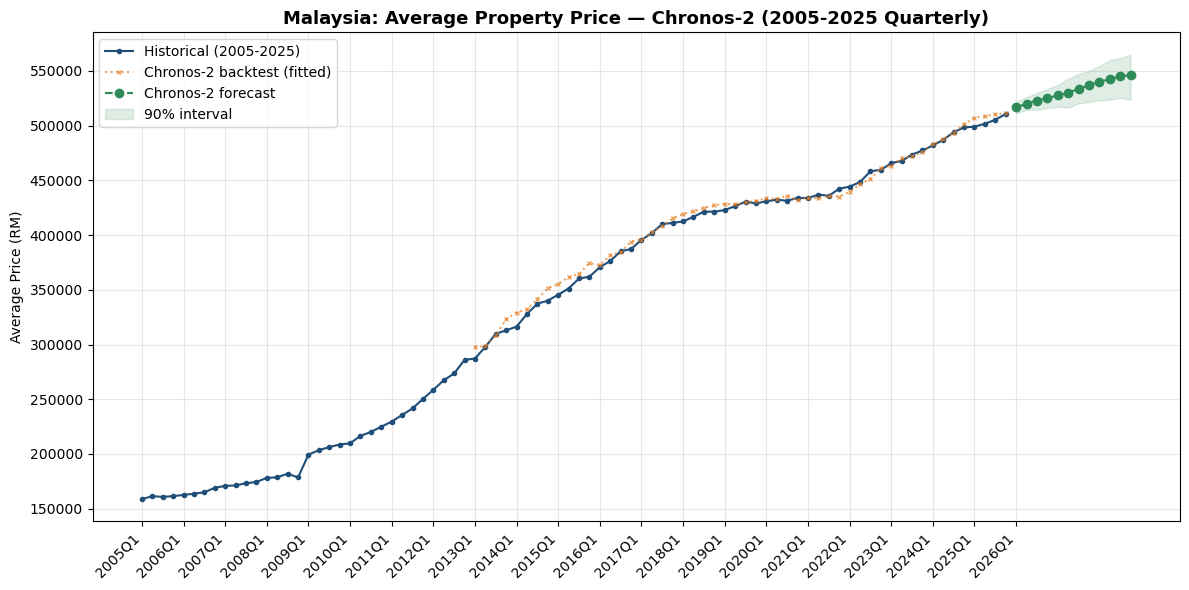


Saved: chronos2_2005_2025_forecast.png, chronos2_2005_2025_backtest.csv, chronos2_2005_2025_forecast_next4.csv


In [8]:
# 6. Chart
# ---------------------------------------------------------------------------
df["period_label"] = df["Year"].astype(str) + df["Quarter"]
forecast_df["period_label"] = forecast_df["Year"].astype(str) + forecast_df["Quarter"]
 
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(len(df)), df["AveragePrice"], marker="o", markersize=3, color="#1f4e79", label="Historical (2005-2025)")
backtest_x = range(MIN_TRAIN, len(df))
ax.plot(backtest_x, backtest_df["y_pred"], marker="x", linestyle=":", color="#e67e22", markersize=3, label="Chronos-2 backtest (fitted)", alpha=0.7)
future_x = range(len(df), len(df) + 12)
ax.plot(future_x, forecast_df["0.5"], marker="o", linestyle="--", color="#2e8b57", label="Chronos-2 forecast")
ax.fill_between(future_x, forecast_df["0.05"], forecast_df["0.95"], color="#2e8b57", alpha=0.15, label="90% interval")
tick_positions = list(range(0, len(df) + 4, 4))
tick_labels = list(df["period_label"]) + list(forecast_df["period_label"])
ax.set_xticks(tick_positions)
ax.set_xticklabels([tick_labels[i] for i in tick_positions], rotation=45, ha="right")
ax.set_title("Malaysia: Average Property Price — Chronos-2 (2005-2025 Quarterly)", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Price (RM)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("chronos2_2005_2025_forecast.png", dpi=150)
plt.show()
 
backtest_df.to_csv("chronos2_2005_2025_backtest.csv", index=False)
forecast_df.to_csv("chronos2_2005_2025_forecast_next4.csv", index=False)
print("\nSaved: chronos2_2005_2025_forecast.png, chronos2_2005_2025_backtest.csv, "
      "chronos2_2005_2025_forecast_next4.csv")

In [9]:
# Covariate Analysis
# 1. Reusable backtest function -- takes a list of covariates to use
# ---------------------------------------------------------------------------
def run_backtest(covariate_cols):
    context_df = pd.DataFrame({
        "id": "malaysia",
        "timestamp": df["Period"],
        "target": df["AveragePrice"],
        **{c: df[c] for c in covariate_cols},
    })
    rows = []
    for i in range(MIN_TRAIN, len(df)):
        past = context_df.iloc[:i]
        future_covs = context_df.iloc[i:i + 1][["id", "timestamp"] + covariate_cols]
        pred_df = pipeline.predict_df(
            past, future_df=future_covs, prediction_length=1,
            quantile_levels=[0.5],
            id_column="id", timestamp_column="timestamp", target="target",
        )
        y_pred = float(pred_df["0.5"].iloc[0])
        rows.append({"period": df["Period"].iloc[i], "y_true": df["AveragePrice"].iloc[i], "y_pred": y_pred})
    result = pd.DataFrame(rows)
    mape = np.mean(np.abs((result["y_true"] - result["y_pred"]) / result["y_true"]))
    mae = np.mean(np.abs(result["y_true"] - result["y_pred"]))
    return mape, mae, result

In [10]:
# 2. Baseline: all covariates
# ---------------------------------------------------------------------------
print("Running baseline (all covariates)...")
baseline_mape, baseline_mae, _ = run_backtest(COVARIATE_COLS)
print(f"Baseline MAPE: {baseline_mape:.2%}  MAE: {baseline_mae:,.0f}\n")

Running baseline (all covariates)...
Baseline MAPE: 1.08%  MAE: 4,138



In [13]:
# 3. Ablation: drop one covariate at a time
# ---------------------------------------------------------------------------
ablation_results = []
for drop_col in COVARIATE_COLS:
    reduced_cols = [c for c in COVARIATE_COLS if c != drop_col]
    print(f"Running without '{drop_col}'...")
    mape, mae, _ = run_backtest(reduced_cols)
    delta = mape - baseline_mape  # positive = removing it HURT accuracy -> it was helpful
    ablation_results.append({
        "removed_covariate": drop_col,
        "MAPE_without": mape,
        "MAE_without": mae,
        "delta_vs_baseline": delta,
        "interpretation": "helpful (removing hurt accuracy)" if delta > 0.002
                           else ("unhelpful/noise (removing improved or no change)" if delta < -0.002
                                 else "negligible effect"),
    })
 
ablation_df = pd.DataFrame(ablation_results).sort_values("delta_vs_baseline", ascending=False)
 
print("\n=== Covariate importance ranking (Chronos-2, AveragePrice) ===")
print(f"Baseline (all covariates) MAPE: {baseline_mape:.2%}\n")
print(ablation_df.to_string(index=False))
print("\nHow to read this: a POSITIVE delta means removing that covariate made")
print("forecasts WORSE -> it was contributing real predictive value.")
print("A NEGATIVE or near-zero delta means the model did fine (or better)")
print("without it -> it likely wasn't adding much beyond noise/overfitting risk.")
 
ablation_df.to_csv("chronos2_price_covariate_ablation.csv", index=False)

Running without 'OPR'...
Running without 'CPI'...
Running without 'MHPI'...
Running without 'MedianIncome'...
Running without 'Population'...
Running without 'GDP'...
Running without 'HOC_dummy'...
Running without 'COVID_dummy'...
Running without 'Q2_dummy'...
Running without 'Q3_dummy'...
Running without 'Q4_dummy'...

=== Covariate importance ranking (Chronos-2, AveragePrice) ===
Baseline (all covariates) MAPE: 1.08%

removed_covariate  MAPE_without  MAE_without  delta_vs_baseline    interpretation
              OPR      0.011856  4540.660313           0.001096 negligible effect
     MedianIncome      0.011350  4372.826538           0.000590 negligible effect
       Population      0.011186  4303.901058           0.000426 negligible effect
              CPI      0.010935  4182.404832           0.000174 negligible effect
              GDP      0.010924  4163.632019           0.000164 negligible effect
             MHPI      0.010561  4097.618077          -0.000199 negligible effect
  